## PARIS inverse modelling results

This notebook contains options to plot and compare results from different inverse models. These variables can all be investigated:

- Posterior and prior country fluxes, total from all sectors
- Posterior, prior and observed modelled total mole fractions
- Posterior and prior modelled baseline mole fractions
- Posterior and prior spatial fluxes

Future updates may include:

- Sector-level emissions
- Comparison between each model's country/region definition

### Notebook setup:

1. Edit the `data_dir` to point towards where the model output is.

2. Update the `model_filenames` dictionary to point towards the experiment/model you want to plot. Update the `model_labels` and `model_colors` dictionaries, these change how each model is labelled in the plots.

3. Run the cell below, before running any of the plotting code.

In [1]:
%load_ext autoreload
%autoreload 2
import PARIS_inversion_results as func

data_dir = '/project/paris/inverse_modelling/'

model_filenames = {
'rhime':'RHIME_NAME_EUROPE_EDGAR_rhime_obs_rhime_baseline_optimized',
'rhime_13':'RHIME_NAME_EUROPE_EDGAR_rhime_obs_rhime_baseline_optimized_13sites',
'rhime_26':'RHIME_NAME_EUROPE_EDGAR_rhime_obs_rhime_baseline_optimized_26sites',
'rhime_36':'RHIME_NAME_EUROPE_EDGAR_rhime_obs_rhime_baseline_optimized_36sites',
'rhime_FrFlat':'RHIME_NAME_EUROPE_EDGAR-FrFlat_rhime_obs_rhime_baseline_optimized_36sites',
'rhime_WetCHARTs':'RHIME_NAME_EUROPE_EDGAR-WetCHARTs_rhime_obs_rhime_baseline_optimized_36sites',

'elris':'ELRIS_NAME_EUROPE_EDGAR_elris_obs_elris_baseline_optimized',
'elris_13':'ELRIS_NAME_EUROPE_EDGAR_std_13sites',
'elris_26':'ELRIS_NAME_EUROPE_EDGARandWETLANDS_std_26sites',
'elris_35':'ELRIS_NAME_EUROPE_EDGARandWETLANDS_std_35sites',
'elris_intemobs':'ELRIS_NAME_EUROPE_EDGAR_intem_obs_elris_baseline_optimized',
'elris_intemobsbl':'ELRIS_NAME_EUROPE_EDGAR_intem_obs_intem_baseline_fixed',
'elris_intembl':'ELRIS_NAME_EUROPE_EDGAR_elris_obs_intem_baseline_fixed',
'elris_flat':'ELRIS_NAME_EUROPE_FLAT_elris_obs_elris_baseline_optimized',

'intem':'InTEM_NAME_EUROPE_EDGAR_intem_obs_intem_baseline_optimized',
'intem_13':'InTEM_NAME_EUROPE_EDGAR_13sites_intem_obs_intem_baseline_optimized',
'intem_33':'InTEM_NAME_EUROPE_EDGAR_33sites_intem_obs_intem_baseline_optimized',
'intem_26':'InTEM_NAME_EUROPE_EDGAR_33sites_no_mountain_intem_obs_intem_baseline_optimized',
'intem_allobs':'InTEM_NAME_EUROPE_EDGAR_all_obs_intem_baseline_optimised',
'intem_flat':'InTEM_NAME_EUROPE_FLAT_intem_obs_intem_baseline_optimized',
'intem_flat_allobs':'InTEM_NAME_EUROPE_FLAT_all_obs_intem_baseline_optimized'}


model_labels = {
'rhime':'RHIME',
'rhime_13':'RHIME 13 sites',
'rhime_26':'RHIME 26 sites',
'rhime_36':'RHIME 31 sites, EDGAR',
'rhime_FrFlat':'RHIME 31 site, EDGAR - France prior flat',
'rhime_WetCHARTs':'RHIME 31 site, EDGAR + WetCHARTs',

'elris':'ELRIS',
'elris_13':'ELRIS 13 sites',
'elris_26':'ELRIS 26 sites, EDGAR + WetCHART',
'elris_33':'ELRIS 33 sites',
'elris_35':'ELRIS 35 sites, EDGAR + WetCHART',
'elris_intemobs':'ELRIS intem obs',
'elris_intemobsbl':'ELRIS intem obs/baseline',
'elris_intembl':'ELRIS intem baseline',
'elris_flat':'ELRIS flat',

'intem':'InTEM',
'intem_13':'InTEM 13 sites',
'intem_26':'InTEM 26 sites',
'intem_33':'InTEM 33 sites',
'intem_allobs':'InTEM all obs',
'intem_flat':'InTEM flat',
'intem_flat_allobs':'InTEM flat all obs'}

# model_colors = {
# 'rhime':['green','lightgreen'],
# 'rhime_13':['green','lightgreen'],
# 'rhime_26':['blue','lightblue'],
# 'rhime_36':['purple','mediumpurple'],
# 'rhime_allobs':['blue','lightblue'],
# 'rhime_intemobs':['blue','lightblue'],
# 'rhime_intemobsbl':['blue','lightblue'],
# 'rhime_intembf':['blue','lightblue'],
# 'rhime_flat':['blue','lightblue'],
# 'rhime_flat_allobs':['blue','lightblue'],
# 'rhime_flat_allobs_new':['gold','khaki'],
# 'rhime_truncated':['gold','khaki'],

# 'elris':['purple','mediumpurple'],
# 'elris_13':['purple','mediumpurple'],
# 'elris_33':['red','lightsalmon'],
# 'elris_intemobs':['purple','mediumpurple'],
# 'elris_intemobsbl':['purple','mediumpurple'],
# 'elris_intembl':['purple','mediumpurple'],
# 'elris_flat':['purple','mediumpurple'],

# 'intem':['red','lightsalmon'],
# 'intem_13':['red','lightsalmon'],
# 'intem_26':['green','lightgreen'],
# 'intem_33':['cyan','lightcyan'],
# 'intem_allobs':['cyan','lightcyan'],
# 'intem_flat':['cyan','lightcyan'],
# 'intem_flat_allobs':['cyan','lightcyan']}

experiments = {
    '13':['rhime_13','intem_13','elris_13'],
    '26':['rhime_26','intem_26','elris_26'],
    '33':['rhime_WetCHARTs','intem_33','elris_35'],
    'prior':['rhime_FrFlat','rhime_WetCHARTs','rhime_36'],
    'r':['rhime_13','rhime_26','rhime_36'],
    'i':['intem_13','intem_26','intem_33'],
    'e':['elris_26','elris_35']}

NOTE: If plotting units or scales look odd, edit species_info.json to fix this.


### 1. Timeseries of country/region fluxes

##### Edit and run this cell to choose inputs:

In [2]:
###################################
### edit variables in this block
species = 'ch4'
models = experiments['33']
period_override = None # ['monthly',]*3  #use to override standard inversion periods, must be a list the same length as models, e.g. ['monthly','yearly']
start_date = '2018-01-01' #inclusive
end_date = '2023-01-01' #not inclusive
###################################

ds_all_flux = func.read_flux(data_dir,species,models,model_filenames,period_override=period_override)

ds_all_flux_scaled = {}

for m in models:
    ds_all_flux_scaled[m] = func.slice_flux({m:ds_all_flux[m]},start_date,end_date,scale_units=True,
                                species=species)[m]


Attempting to read data from rhime_WetCHARTs
Reading data from: /project/paris/inverse_modelling/RHIME/ch4/RHIME_NAME_EUROPE_EDGAR-WetCHARTs_rhime_obs_rhime_baseline_optimized_36sites_ch4_monthly.nc
Done!

Attempting to read data from intem_33
Reading data from: /project/paris/inverse_modelling/InTEM/ch4/InTEM_NAME_EUROPE_EDGAR_33sites_intem_obs_intem_baseline_optimized_ch4_monthly.nc
Done!

Attempting to read data from elris_35
Reading data from: /project/paris/inverse_modelling/ELRIS/ch4/ELRIS_NAME_EUROPE_EDGARandWETLANDS_std_35sites_CH4_monthly.nc
Done!

Masking data from rhime_WetCHARTs
Scaling rhime_WetCHARTs units by 1000000000.0

Masking data from intem_33
Scaling intem_33 units by 1000000000.0

Masking data from elris_35
Scaling elris_35 units by 1000000000.0
Scaling covariance units in elris_35 by 1e+18


In [3]:
import numpy as np
model_colors = dict()
if np.unique([m.split('_')[0] for m in models]).size==len(models):
    for m in models:
        if m.split('_')[0] == 'rhime':
            model_colors[m] = ['green','lightgreen'] 
        elif m.split('_')[0] == 'elris':
            model_colors[m] = ['purple','mediumpurple']
        elif m.split('_')[0] == 'intem':
            model_colors[m] = ['red','lightsalmon']
else:
    for m in models:
        if '13' in m:
            model_colors[m] = ['green','lightgreen'] 
        elif '26' in m:
            model_colors[m] = ['purple','mediumpurple']
        elif '33' in m or '36' in m or '35' in m:
            model_colors[m] = ['red','lightsalmon']
        elif 'FrFlat' in m:
            model_colors[m] = ['green','lightgreen'] 
        elif 'WetCHARTs' in m:
            model_colors[m] = ['purple','mediumpurple']
    

#### Timeseries of country fluxes:

[ True  True  True  True  True  True  True  True  True  True  True  True
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False]
[0.58257481 0.41924499 0.18214109 0.60546234 0.44906566 0.35614449
 0.22792723 0.29098123 0.15116851 0.25560971 0.37031563 0.33666987
 0.49538165 0.44700905 0.6657296  0.5925739  0.50513258 0.58603719
 0.31656565 0.10636137 0.60908423 0.39745536 0.42340052 0.48916274
 0.5803949  0.09366026 0.22945633 0.32969162 0.15729028 0.38326014
 0.66187075 0.63977978 0.68922488 0.68823515 0.36394159 0.78559862
 0.66188134 0.44884543 0.4610656  0.76157543 0.73299877 0.17924486
 0.6183119  0.56411096 0.16707085 0.86566201 0.3514865  0.47303726
 0.73660416 0.81596849 0.31308987 0.50782135 0.38427076 0.65872246]
[0.58257481 0.41924499 0.18214109 0.60546234 0.44906566 0.35614449

ValueError: x and y must have same first dimension, but have shapes (60,) and (5,)

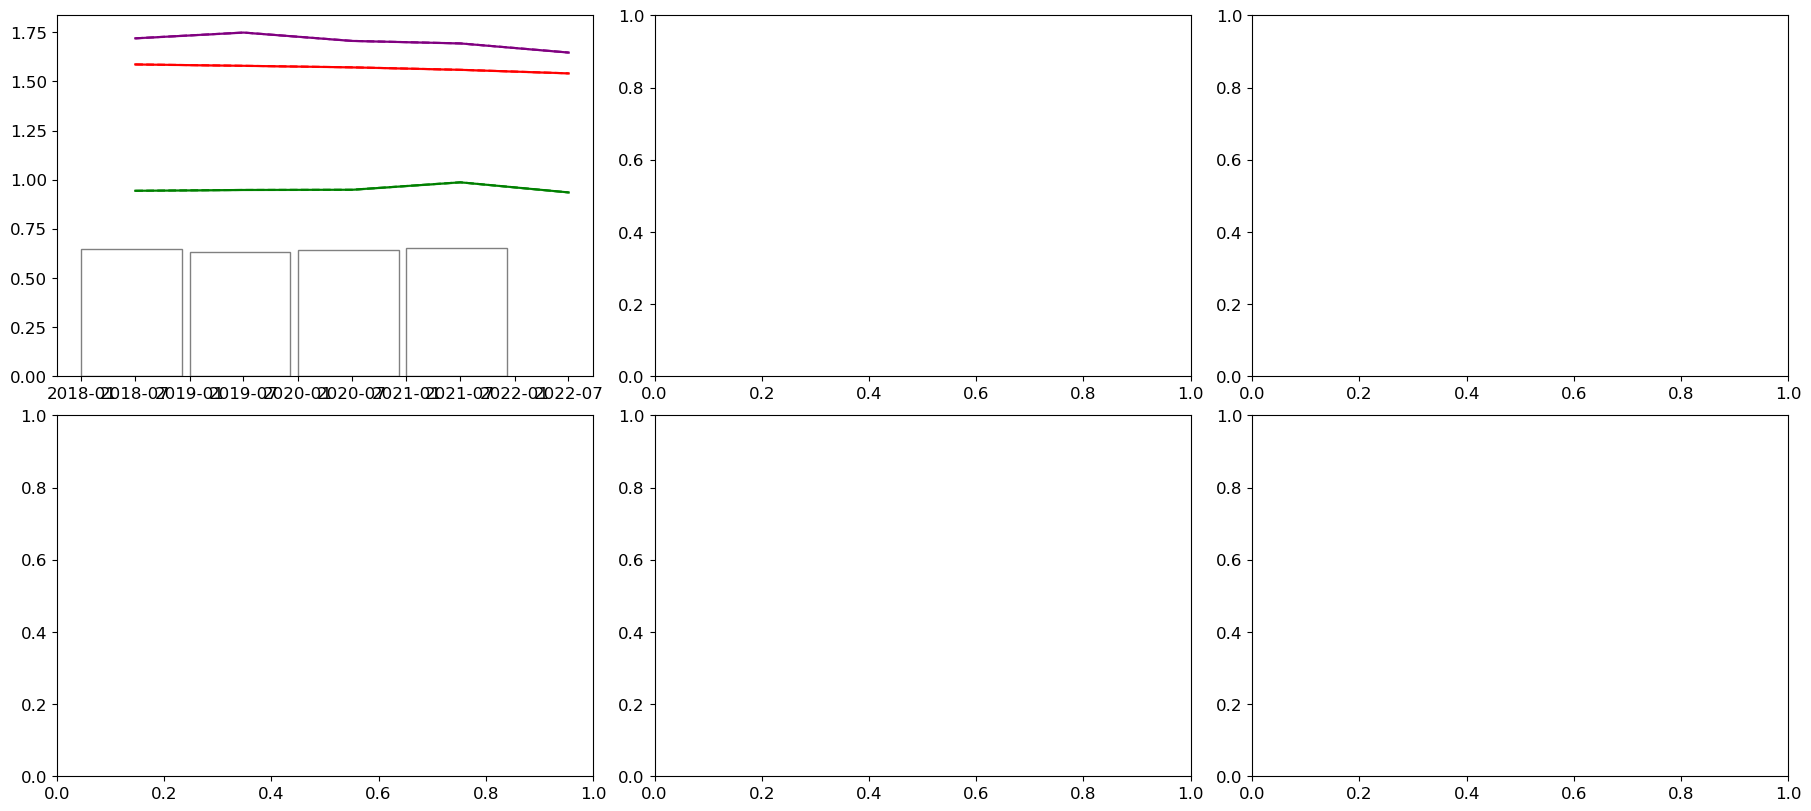

In [4]:
###################################
### edit variables in this block
plot_regions = ['IRELAND','UK','FRANCE','GERMANY','BENELUX','NW_EU2'] #works best with 6 countries but can run with any number (will always create at least 4 subplots though)
plot_inventory = True
inventory_years = None #If None, plots most recent. Or can choose list of years: ['2022','2023']
fix_y_axes = False #if True: all y axis limits are the same, if False: each y axis is relative to the data
                     #if a list of floats (e.g. [0,0.1]) applies these limit to all axes
add_prior_unc = False #if True: plots prior uncertainty as shaded area
set_global_leg = True #If True, plots one single legend instead of one legend per subplot.
country_codes_as_titles = False #If True, lists 3-letter country codes under region names in subplot titles
plot_separate = True #If True, includes all model results as separate lines
plot_combined = True #If True, combined results, averaged from all models
plot_separate_by_year = True #If True, plot average flux over each year
period_override = None #use to override standard inversion periods, must be a list the same length as models, e.g. ['monthly','yearly']
###################################

fig = func.plot_country_flux(ds_all_flux_scaled,species,plot_regions,model_labels,
                             model_colors,
                             plot_inventory,inventory_years,data_dir,fix_y_axes,
                             add_prior_unc,set_global_leg,country_codes_as_titles=country_codes_as_titles,
                             plot_separate=plot_separate,plot_combined=plot_combined,
                             plot_separate_by_year=plot_separate_by_year,period_override=period_override)

Save plot here:

In [ ]:
#output_path = '/home/h02/aramsden/results/PARIS_results_comparison/fixed_baseline/InTEM_Feb2024_E-D_fixed_baseline_comparison_countryfluxes.png'

#fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

### 2. Modelled and observed mole fractions and/or baselines

##### Edit and run this cell to choose inputs and read in the data:

In [ ]:
###################################
### edit variables in this block
species = 'hfc143a' 
site = 'MHD'
models = ['intem_inner','intem_outer']#'rhime',]
period_override = None  #use to override standard inversion periods, must be a list the same length as models, e.g. ['monthly','yearly']
start_date = '2018-01-01' #inclusive
end_date = '2019-01-01'   #not inclusive

baseline_site = None #'MHD', 'JFJ' or 'CMN'. If None, does not mask by baseline time
###################################

###################################
### options for variables to include in the functions below 
# Yobs                - total observed mole fraction
# uYobs_repeatability - observed repeatability mole fraction uncertainty
# uYobs_variability   - observed variability mole fraction uncertainty
# uYmod               - model mole fraction uncertainty
# uYtotal             - total mole fraction uncertainty
# Yapriori            - prior total mole fraction
# Yapost              - posterior total mole fraction
# YaprioriBC          - prior baseline
# YapostBC            - posterior baseline
# Ybias               - posterior bias added to site
# YaprioriOuter       - prior mole fractions only from outer regions
# YapostOuter         - posterior mole fractions only from outer regions
###################################


ds_all_mf = func.read_mf(data_dir,species,models,model_filenames,period_override=period_override)

ds_all_mf_sliced = func.slice_mf(ds_all_mf.copy(),start_date,end_date,site,baseline_site=baseline_site,
                              data_dir=data_dir,
                              scale_units=True,species=species)

#### Timeseries plot, separated by model:

In [ ]:
fig = func.plot_obs_modelled_separate(ds_all_mf_sliced,species,site,model_labels,
                                      model_colors,
                             include=['Yobs','Yapost'],
                             diff_include=['Yapost'],
                             y_lim=None)

###################################
### Instructions for timeseries plotting: 
# - Add variables that you want to plot in "include"
# - To plot the histogram of the variables in "include", leave "diff_include" empty
# - To plot the histogram of Obs-variable, add the desired variable to be subtracted in "diff_include" (default value of "diff_include" = Yapost)
# - To erase uncertainty bars around the mean values of Yobs and Yapost set "add_unc" to False (default value of "add_unc" = True)
# - To choose y axis limits set y_lim=[min_value,max_value]
###################################

#### Timeseries plot, all models together:

In [ ]:
fig = func.plot_obs_modelled_together(ds_all_mf_sliced,species,site,model_labels,
                                      model_colors,
                             include=['Yapost'],
                             diff_include=['Yapost'],
                             y_lim=None)

#### Absolute differences between two models:

In [ ]:
fig = func.plot_obs_diff(ds_all_mf_sliced,species,site,model_labels,
                                      model_colors,
                             include=['Yapost'],
                             diff_include=['Yapost'],
                             y_lim=None)

#### Calculate and plot stats for the fit to obs:

In [ ]:
ds_all_allsites = func.slice_mf(ds_all_mf.copy(),start_date,end_date,site=None,
                              baseline_site=baseline_site,
                              data_dir=data_dir,
                              scale_units=True,species=species)

pearson,nrmse = func.stats_mf(ds_all_allsites)

fig = func.plot_stats_mf(pearson,nrmse,species,model_labels,
                         model_colors,
                  start_date=start_date,end_date=end_date)

Save plot:

In [ ]:
output_path = None

#fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

### 3. Posterior country fluxes - lat lon grid prior and posterior comparison

##### Edit this cell to choose inputs:

In [ ]:
###################################
### edit variables in this block
species = 'hfc125'
start_date = '2018-01-01' #select the time period to plot (a month or year, depending on the inversion period)
end_date = '2023-01-01' #if end_date doesn't = start_date, a mean average of the whole period will be plotted
models = ['intem','elris']#,'rhime','elris_name']
period_override = None  #use to override standard inversion periods, must be a list the same length as models, e.g. ['monthly','yearly']
###################################

ds_all_flux = func.read_flux(data_dir,species,models,model_filenames,period_override=period_override)

ds_all_flux_scaled = {}

for m in models:
    ds_all_flux_scaled[m] = func.slice_flux({m:ds_all_flux[m]},start_date,end_date,scale_units=True,
                                species=species)[m]

##### Prior and posterior fluxes for all models:

In [ ]:
###################################
### edit variables in this block
plot_area = 'CWEU' #options for: UK, FRANCE, GERMANY, ITALY, SWITZERLAND, NWEU, CWEU, EUROPE
cmap = 'viridis'   #Greens
cmap_diff = 'coolwarm'
c_border = 'floralwhite'    #country boundary colour
plot_site_locations = True #If True, adds markers to plots at locations of obs sites 
plot_point_markers = ['paris','london'] #plot a marker at these locations, options for 'paris', 'london', 'nw_england' (PFC-218 source) or any value [lon,lat]
###################################

fig = func.plot_spatial_flux(ds_all_flux_scaled,species,plot_area,model_labels,
                             cmap=cmap,cmap_diff=cmap_diff,c_border=c_border,
                             period_override=period_override,plot_site_locations=plot_site_locations,
                             plot_point_markers=plot_point_markers)

##### Directly compare posterior fluxes from two models:

In [ ]:
fig = func.plot_spatial_flux_comparison(ds_all_flux_scaled,species,plot_area,model_labels,
                                        cmap=cmap,cmap_diff=cmap_diff,c_border=c_border,
                                        period_override=period_override,
                                        plot_site_locations=plot_site_locations,
                                        plot_point_markers=plot_point_markers)

##### Plot prior, posterior or difference fluxes per time interval:

In [ ]:
###################################
### edit variables in this block
plot_area = 'CWEU'   #options for: UK, FRANCE, GERMANY, ITALY, SWITZERLAND, NWEU, CWEU, EUROPE
cmap = 'coolwarm'    #flux colour (e.g. 'viridis', 'coolwarm')
c_border = 'dimgrey' #country boundary colour (e.g. 'floralwhite', 'dimgrey')
chop_by = 'year'     #time unit of the averaging period (options for 'year', 'month' and 'season')
                     #alternatively, a list of starting dates can be provided (format '2018-01-01')
dt = 2               #number of time steps (in chop_by units) to use in the averaging
                     #if chop_by='season': set dt to a list of lists with the months to use in the average (e.g. dt=[[1,2],[10,11]], will average over Jan-Feb and Oct-Nov)
var = 'posterior_prior_diff'  #variable to be plotted.
                              #options for: 'flux_total_posterior', 'flux_total_prior', 'posterior_prior_diff'
plot_site_locations = True #If True, adds markers to plots at locations of obs sites
plot_point_markers = ['paris','london'] #plot a marker at these locations, options for 'paris', 'london', 'nw_england' (PFC-218 source) or any value [lon,lat]
###################################

fig = func.plot_spatial_flux_per_timestamp(ds_all_flux_scaled,species,plot_area,model_labels,end_date,
                                            cmap=cmap,c_border=c_border,
                                            var=var,chop_by=chop_by,dt=dt,period_override=period_override,
                                            plot_site_locations=plot_site_locations,
                                            plot_point_markers=plot_point_markers)

### 7. Compare region definitions

THIS NEEDS UPDATING TO COMPARE MULTIPLE MODELS - CURRENTLY THESE NEED TO BE INPUT MANUALLY

In [ ]:
species = 'ch4' #select the species you want to plot
plot_region = 'UK' #choose the region mask to plot

In [ ]:
# Read in emissions output

intem = xr.open_dataset(os.path.join(data_dir,f'InTEM_NAME_EUROPE_{intem_species[species]}_{period[m][species]}.nc'))
#rhime = xr.open_dataset(os.path.join(data_dir,f'RHIME_NAME_EUROPE_{species}_{period}.nc'))
#empa = xr.open_dataset(os.path.join(data_dir,f'{empa_name}_FLEXPART_EUROPE_{species}_{period}.nc')) 

try:
    intem_r0 = np.where(intem['countrynames'].values == plot_region)[0][0]
except:
    print(f'No region in InTEM called {plot_region}')

In [ ]:
ax_limits = [-12,25,40,65] #min_lon, max_lon, min_lat, max_lat

fig,ax = plt.subplots(2,3,figsize=(12,6),constrained_layout=True,
                          subplot_kw={'projection':cartopy.crs.PlateCarree()})

for i in range(2):
    for j in range(3):
        ax[i,j].add_feature(cartopy.feature.BORDERS,linestyle=':',edgecolor='black',linewidth=1.)
        ax[i,j].coastlines(resolution='50m',color='black',linewidth=1.)
        ax[i,j].set_extent(ax_limits)
        
#plot intem
ax[0,0].pcolormesh(intem.lon.values,intem.lat.values,intem['region_definitions'][:,:,intem_r0],cmap='Blues',
                 vmin=0,vmax=2)
ax[0,0].set_title(f'InTEM {plot_region} mask')

#plot difference
#ax[1,0].pcolormesh(intem.lon.values,intem.lat.values,
#                   intem['region_definitions'][:,:,intem_r0]-rhime['region_definitions'][:,:,rhime_r0],
#                   cmap='bwr')
ax[1,0].set_title(f'InTEM {plot_region} - RHIME {plot_region}')